## Initialization 

(Age from https://academic.oup.com/mnras/article/507/4/4788/6359151?login=false)

In [1]:
import importlib
import pandas as pd
import numpy as np

In [23]:
clusternames = ['6093'] # change this to run for other clusters.
age_manual = 14 # in Gyr. # ignore if the above is "True".

pathstartswith = '/Users/lakshgupta/Downloads/Personal/P-NGC2808WD/'
clustername = 'ngc' + clusternames[0]

params = pd.read_csv('cluster_param.csv')

met = round(params.loc[params['ID'] == clustername, "[Fe/H]"].values[0], 3)
reddening = round(params.loc[params['ID'] == clustername, "E(B-V)"].values[0], 3)
DM = params.loc[params['ID'] == clustername, "(m-M)V"].values[0]
aDM = round(DM - 3.1*reddening, 2)
d = round(10 * (10 ** ((aDM) / 5)) - (3.1 * (reddening)), 2)
age = round(params.loc[params['ID'] == clustername, "Age"].values[0], 2)
age_err = round(params.loc[params['ID'] == clustername, "Age_err"].values[0], 2)

print("Parameters of " + clustername + " from Harris Catalogue:")
print("RA and DEC: " + str(round(params.loc[params['ID'] == clustername, "RA"].values[0], 4)) + " " + str(round(params.loc[params['ID'] == clustername, "DEC"].values[0], 4)))
print("Metallicity: " + str(met)) # use this metallicity value to dowload models
print("Reddening: " + str(reddening))
print("Absolute Distance Modulus: " + str(DM))
print("Apparent Distance Modulus: " + str(aDM))
print("Distance in pc: " + str(d))
print("Age from Literature: " + str(age) + " Gyr")
print("Age error from Literature: " + str(age_err) + " Gyr")

ageiso = 1000*(age_manual)
ageiso = int(ageiso)
print("IMPORTANT: Age to be used for isochrones: " + str(ageiso) + " Myr.")

metavail = [-1.84, -0.60, -2.14, -1.01, -1.31, -1.62]
whichmetuse = abs((met - metavail)).min()

idx = np.argmin(np.abs(met - metavail))
whichmetuse = metavail[idx]

print("Should use models of metallicity", whichmetuse)

Parameters of ngc6093 from Harris Catalogue:
RA and DEC: 244.26 -22.9761
Metallicity: -1.75
Reddening: 0.18
Absolute Distance Modulus: 15.56
Apparent Distance Modulus: 15.0
Distance in pc: 9999.44
Age from Literature: 13.5 Gyr
Age error from Literature: 1.0 Gyr
IMPORTANT: Age to be used for isochrones: 14000 Myr.
Should use models of metallicity -1.84


In [18]:
import tex # comment this if Python on your system is not "linked" with TeX.
import func_analysis
import func_input

import theoreticalmodels
importlib.reload(theoreticalmodels)
import namingroutine
importlib.reload(namingroutine)
import inputdata
importlib.reload(inputdata)

# following must be loaded as they are used ahead. 
# I have commented the how to use, for example, 'colors' list from namingroutine.py.

models = theoreticalmodels.Initialize(func_input.ReadingModels, pathstartswith)
names = namingroutine.Initialize()
dfclusters_input = inputdata.Initialize(func_input.LoadClusters, pathstartswith, clusternames)

dfclusters = dict(sorted(dfclusters_input['dfclusters'].items()))

In [12]:
# print(models['iso131'])
# print(names['colors'])
# print(dfclusters['ngc2808'])

# dfparams['dfparams'].to_csv('cluster_param.csv', index=False) # to save the cluster parameters in a csv file.

## Pre-analysis checks on models

<Figure size 585.25x413.875 with 0 Axes>

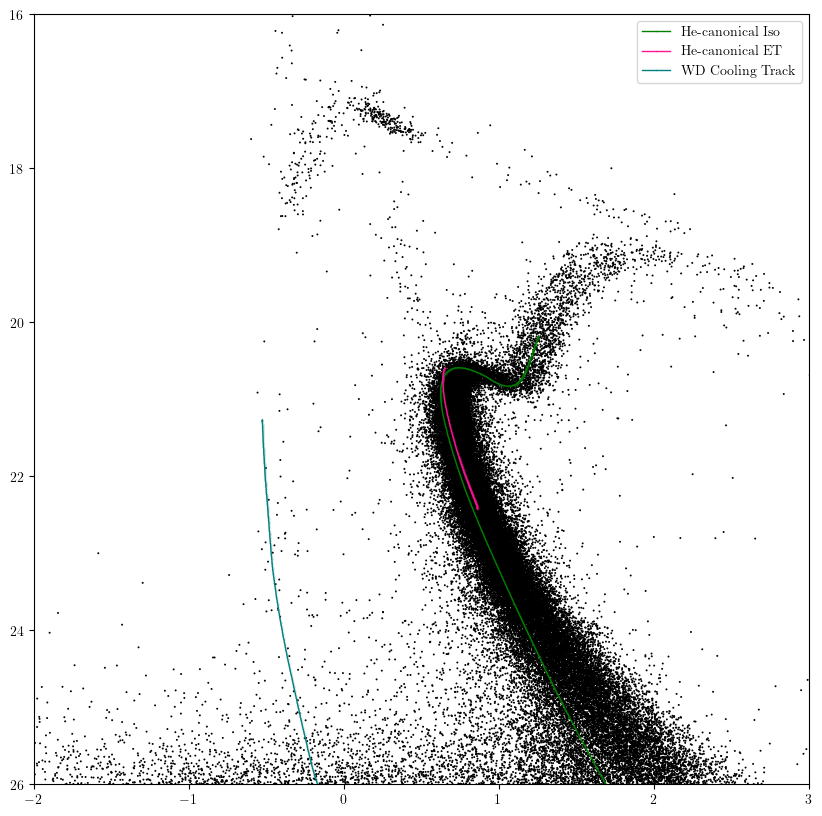

In [ ]:
c_masset = 80
a_masset1 = 70
a_masset2 = 60
wdmass = '054'

# The following models are input for the msto.py and wd.py directly. 
# Please check before calling the MSTO and WD routines. 
# One can skip abundantet1 and abundantet2 by putting wantabund=False.
# 1 Isochrone and 1 ET is essential to run the MSTO routine. 
# 1 WD Model is essential to run the WD routine.

# the apparent distance modulus and reddening value used can be adjusted. 
# I have done this below as adding some value to aDM and reddening.
# One can also artifically redden or de-redden the models. This is done by adding or subtracting some value from 'F336W' filter.

wantabund=False 

c_isohold = models['iso184'][str(ageiso)]
canonicaliso_dict = func_analysis.corrections(aDM+0.1, reddening+0.05, {'main': c_isohold[0:600]})
canonicaliso = canonicaliso_dict['main']  
canonicaliso['F336W'] -= 0.1
# print(canonicaliso)

c_ethold = models['et184_c'][str(c_masset)]
canonicalet_dict = func_analysis.corrections(aDM+0.1, reddening+0.05, {'main': c_ethold[0:300]})
canonicalet = canonicalet_dict['main']
canonicalet['F336W'] -= 0.15

wd_hold = models['wdCOHZ0420'][wdmass]
wdcooling_dict = func_analysis.corrections(aDM+0.01, reddening, {'main': wd_hold})
wdcooling = wdcooling_dict['main'] 
wdcooling['F336W'] -= 0.0

a_et1hold = models['et131_a1'][str(a_masset1)]
abundantet1_dict = func_analysis.corrections(aDM-0.15, reddening-0.025, {'main': a_et1hold[100:350]})
abundantet1 = abundantet1_dict['main']
abundantet1['F336W'] -= 0.1

a_et2hold = models['et131_a2'][str(a_masset2)]
abundantet2_dict = func_analysis.corrections(aDM-0.11, reddening, {'main': a_et2hold[100:350]})
abundantet2 = abundantet2_dict['main']
abundantet2['F336W'] -= 0.17

import matplotlib.pyplot as plt


dictholdmodels_ms = {'He-canonical Iso': canonicaliso, 
                     'He-canonical ET': canonicalet, 
                     'He-abundant ET 1': abundantet1, 
                     'He-abundant ET 2': abundantet2, 
                     'WD Cooling Track':wdcooling}

plt.tight_layout()
plt.rcParams['figure.dpi']=100
fig=plt.figure(figsize=(10,10))

plt.scatter(dfclusters[clustername]['F275W'] - dfclusters[clustername]['F336W'], dfclusters[clustername]['F275W'], 
            marker = 'o', s=2, alpha=1, color='black', edgecolors='none')

for i, (label, modelhere) in enumerate(dictholdmodels_ms.items()):
    if not wantabund and i in (2, 3):
        continue  
    plt.plot(modelhere['F275W'] - modelhere['F336W'],
             modelhere['F275W'],
             color=names['colors'][i], lw=1, linestyle='-', markersize=0.1,
             marker='o', label=label)

plt.ylim(16, 26)
plt.xlim(-2, 3)
plt.gca().invert_yaxis()
plt.legend()

plt.show()     

## Routines for Star Count Evolutionary Times Analysis

### Main Sequence TurnOff Stars

MSTO Analysis being run for ngc6093.
delta M = 0.004. Following numbers are for this.
0.6125990063463209 0.8086160821032107
0.6125990063463209 0.8086160821032107
If the two pairs above are identical then the bluelimit, redlimit and sigmacut are correctly set.
Magnitude Range: 20.849 - 21.038 = 0.189 and Color Range: 1.435 - 0.014 = 1.421
Rough MSTO Selection Star Count (in darkgreen): 1922
T-MSTO point: 0.63, 20.96
Following counts are not completeness corrected (indicated as '0' below).
SC/CT (He-Can): UB (pink): (938, 0) / 415.14, LB (purple): (727, 0) / 332.11
Total: 1665/747.25


<Figure size 409.675x289.712 with 0 Axes>

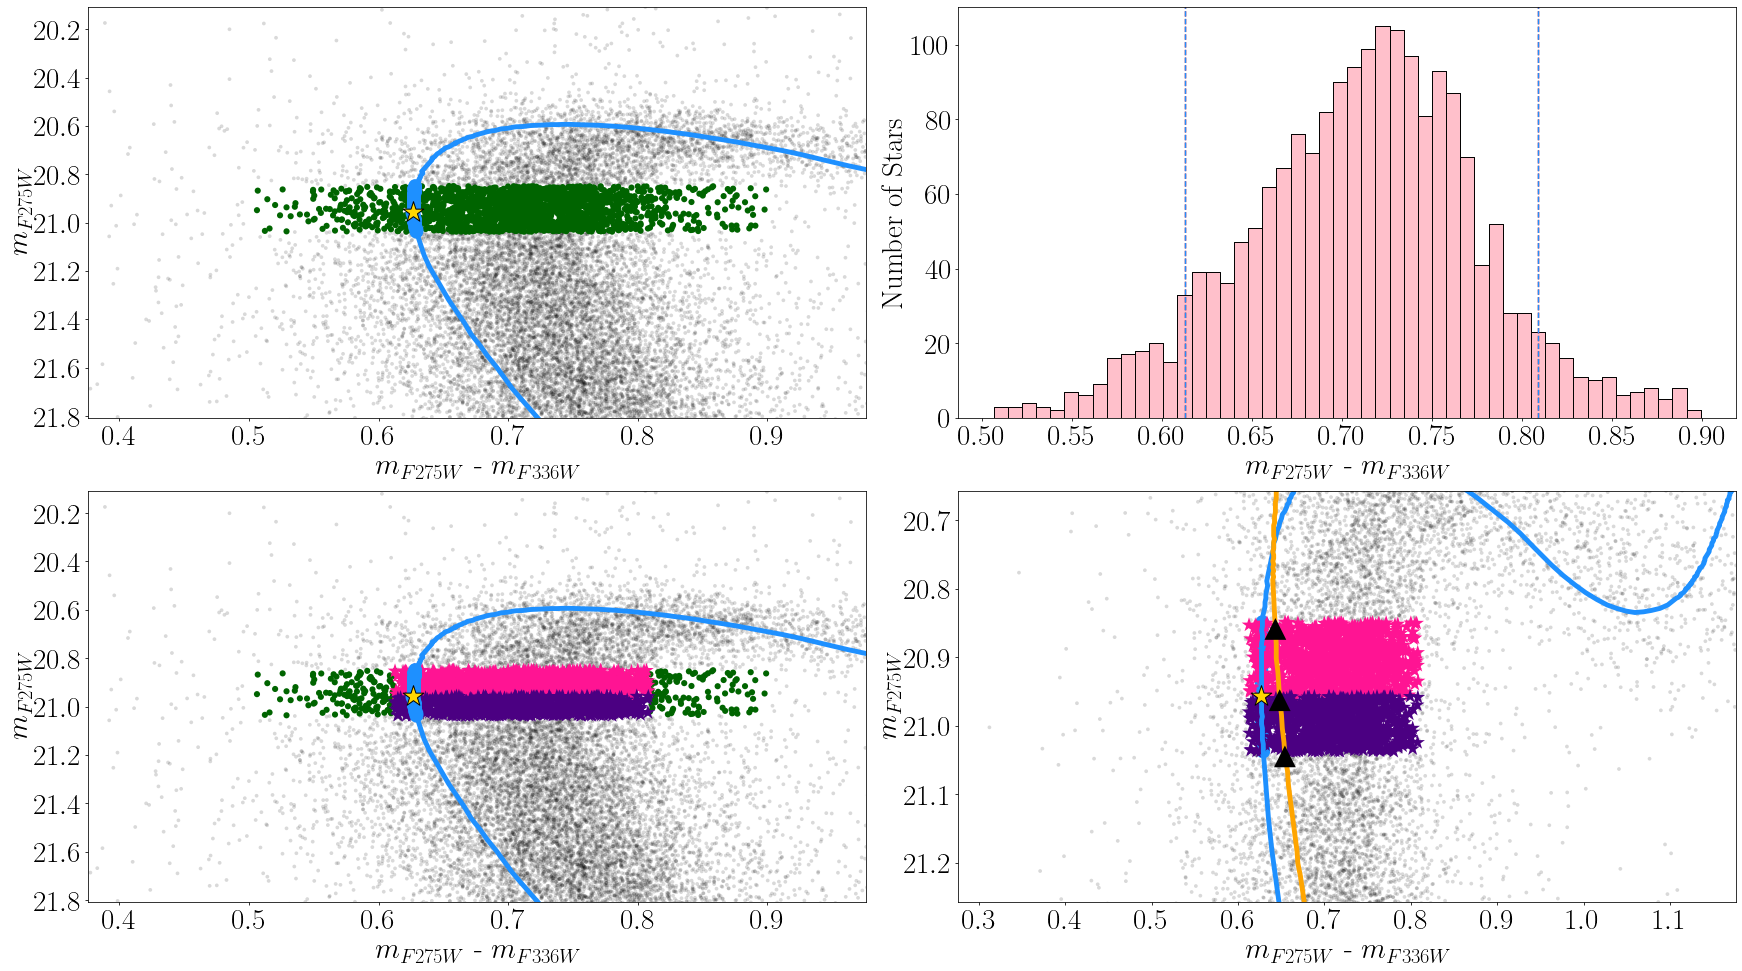

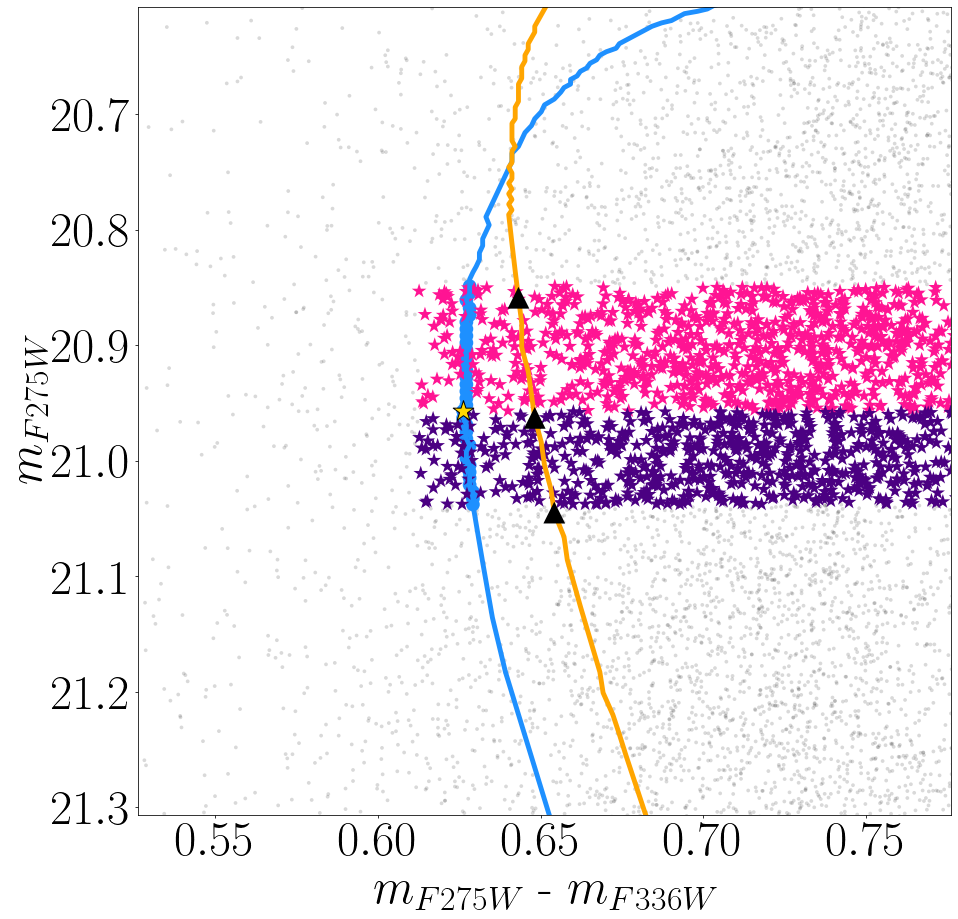

In [35]:
import msto
importlib.reload(msto)

Completeness=False

# to select stars with pm > 80.
# df = func_analysis.cleandata(dfclusters[clustername], 80) 

#  to remove stars with dF275W < 1 and dF336W < 1
df = dfclusters[clustername][~((dfclusters[clustername]['dF275W'] > 1) & (dfclusters[clustername]['dF336W'] > 1))]

msto_ret = msto.initialize(df,
                ageiso, c_masset, str(a_masset1), str(a_masset2),
                canonicaliso, canonicalet, abundantet1, abundantet2,
                clustername, wantabund, Completeness,
                delalpholder = [0.0040], # this can be loaded with more values.
                g=0, dpi=70,
                bluelimit = 0.5, redlimit = 0.9, sigmacut = 1.5, 
                wantcsv=False, wantlegend=False, # printing legend won't be required since everything is being printed as output in text.
                )

# for spatial plot
SPUpperMS = msto_ret['concatnewupper'] 
SPLowerMS = msto_ret['concatnewlower'] 

# SC for ratio calculation (either Completeness or not)
MSSC_c = len(msto_ret['MSSC_c']) 
if Completeness:
    MSSC_c_comp = len(msto_ret['MSSC_c_comp']) 

# CT for ratio calculation (can be more than 1 since He-enhanced models can also be used)
MSCT_c = abs(msto_ret['MSCT_c']) 
if wantabund:
    MSCT_a1 = msto_ret['MSCT_a1'] 
    MSCT_a2 = msto_ret['MSCT_a2'] 

### White Dwarfs

WD Analysis being run for ngc6093.
For the potential WDs, the color selection: -0.6 to 0
For the ``bright'' WDs, the color selection: -0.25 to -1
Bright WDs start from: 19
No completeness function was read. `0+0=0' below denotes that there are no completeness corrected counts.
Upper lifetime - 6.274 Myrs
Lower lifetime - 32.401 Myrs


<Figure size 585.25x413.875 with 0 Axes>

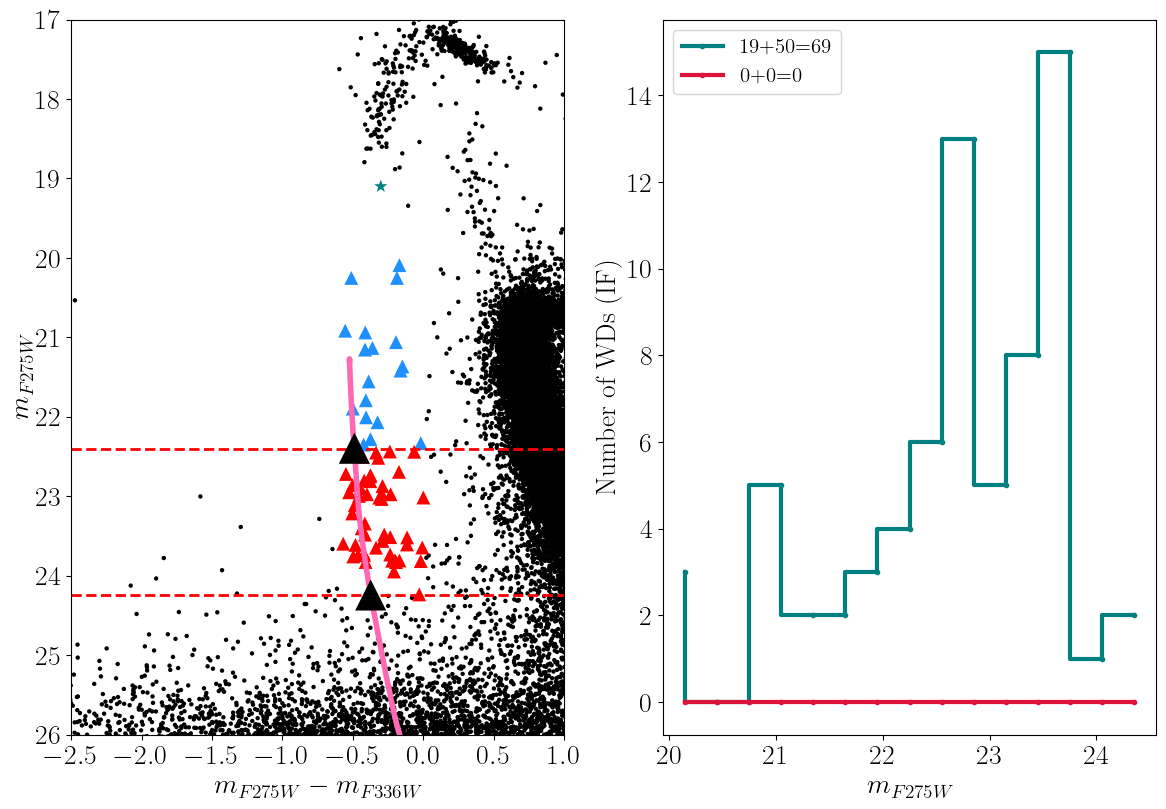

In [37]:
import wd
importlib.reload(wd)

wd_ret = wd.initialize(dfclusters[clustername],
                wdcooling, clustername,
                max_allowed_mag=24.243, min_allowed_mag=20, # these numbers come from AST
                dpi=100,
                binsize=0.3, # can be increased or decreased as per choice.
                division=22.4, # can be increased or decreased as per cluster.
                min_mag=17, max_mag=26, min_col=-2.5, max2=1,
                wdcolmin = -0.6, wdcolmax=0,
                wdcolminbri = -0.25, wdcolmaxbri=-1,
                briwdstart = 19,
                wantlegend=False, Completeness=False
              )

SPUpperWD = wd_ret['bin1']
SPLowerWD = wd_ret['bin2'] 
SPBrightWD = wd_ret['dfwdcalbright']

WDCTup = wd_ret['WDCTup']
WDSCup = wd_ret['sum_values_upper_ncorr']
WDSCup_corr = wd_ret['sum_values_upper_corr']

WDCTlo = wd_ret['WDCTlo']
WDSClo = wd_ret['sum_values_lower_ncorr'] + WDSCup
WDSClo_corr = wd_ret['sum_values_lower_corr'] + WDSCup_corr

### Red Giant Branch Stars

### Horizontal Branch

### Blue Straggler Stars

## Ratio Calculation

### WD/MSTO

In [38]:
import ratios
importlib.reload(ratios)

rationumholder = {0: [WDSCup, MSSC_c, WDCTup, MSCT_c],
                  1: [WDSClo, MSSC_c, WDCTlo, MSCT_c]
                  }

ratios.initialize(rationumholder)

Pop A,Pop B,Star Count,Crossing Time,Note
"19, 6.274","1665, 747.25",0.011 ± 0.003,0.008 ± 0.001,Population A is in excess by 27.27%
"69, 32.401","1665, 747.25",0.041 ± 0.005,0.043 ± 0.006,Population B is in excess by 4.65%


## Radial and Spatial Distributions of Various Stellar Evolutionary Phases

In [ ]:
clusterlist = {
    clustername: dfclusters[clustername]
}

import spatialplot
importlib.reload(spatialplot)
import plotcmd
importlib.reload(plotcmd)

# 'afterhowmany' is the after how many rows shall the code pick the next row to print 
# - aim is to reduce computational time. 
spatialplot.fewclusters(clusterlist, dpi=100, legend=True, afterhowmany=3) 

In [ ]:
import pandas as pd
SPhb = pd.DataFrame() # SPhb under work for generalization.

import stelpha_splplt_raddist
importlib.reload(stelpha_splplt_raddist)

stelpha_splplt_raddist.initialize(func_analysis.cleandata(dfclusters[clustername], -12), 
                                  func_analysis.cleandata(dfclusters[clustername], 80), 
                                  racluster, deccluster, 
                                  SPUpperMS, SPLowerMS,
                                  SPUpperWD, SPLowerWD, SPBrightWD,
                                  SPhb,
                                  singlecolor=False, 
                                  hb=False,
                                  dpi=100)